In [16]:
import pandas as pd
import numpy as np

In [17]:
# Load the file
co2_raw = pd.read_csv("CO2Emis.csv", sep=";")

# Basic inspection
print("Shape of raw dataset:", co2_raw.shape)
print("\nColumn names:")
print(co2_raw.columns.tolist())

print("\nFirst 5 rows:")
display(co2_raw.head())
print("\nData types:")
print(co2_raw.dtypes)

Shape of raw dataset: (315611, 4)

Column names:
['Minutes5UTC', 'Minutes5DK', 'PriceArea', 'CO2Emission']

First 5 rows:


,Minutes5UTC,Minutes5DK,PriceArea,CO2Emission
0,2022-01-01 00:00:00,2022-01-01 01:00:00,DK1,"63,000000"
1,2022-01-01 00:05:00,2022-01-01 01:05:00,DK1,"62,000000"
2,2022-01-01 00:10:00,2022-01-01 01:10:00,DK1,"63,000000"
3,2022-01-01 00:15:00,2022-01-01 01:15:00,DK1,"64,000000"
4,2022-01-01 00:20:00,2022-01-01 01:20:00,DK1,"63,000000"



Data types:
Minutes5UTC    str
Minutes5DK     str
PriceArea      str
CO2Emission    str
dtype: object


In [18]:
#Keep UTC only, convert timestamp to datetime, convert CO₂ to numeric, and verify DK1
# Step 2: Keep UTC only and convert columns to proper types

# Keep only the columns we need for the UTC workflow
co2 = co2_raw.drop(columns=["Minutes5DK"], errors="ignore").copy()

# Convert UTC timestamp column to datetime
co2["Minutes5UTC"] = pd.to_datetime(co2["Minutes5UTC"], errors="coerce")

# Convert CO2Emission from comma-decimal text to numeric
co2["CO2Emission"] = (
    co2["CO2Emission"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
co2["CO2Emission"] = pd.to_numeric(co2["CO2Emission"], errors="coerce")

# Check PriceArea values
print("Unique PriceArea values:")
print(co2["PriceArea"].unique())

# Check data types after conversion
print("\nData types after conversion:")
print(co2.dtypes)

# Check if any timestamps or CO2 values failed to convert
print("\nMissing values after conversion:")
print(co2[["Minutes5UTC", "CO2Emission"]].isna().sum())

#shape
print("Shape of  dataset:", co2.shape)

# Show first 5 rows
print("\nFirst 5 cleaned rows:")
display(co2.head())


Unique PriceArea values:
<StringArray>
['DK1']
Length: 1, dtype: str

Data types after conversion:
Minutes5UTC    datetime64[us]
PriceArea                 str
CO2Emission           float64
dtype: object

Missing values after conversion:
Minutes5UTC    0
CO2Emission    0
dtype: int64
Shape of  dataset: (315611, 3)

First 5 cleaned rows:


,Minutes5UTC,PriceArea,CO2Emission
0,2022-01-01 00:00:00,DK1,63.0
1,2022-01-01 00:05:00,DK1,62.0
2,2022-01-01 00:10:00,DK1,63.0
3,2022-01-01 00:15:00,DK1,64.0
4,2022-01-01 00:20:00,DK1,63.0


2022–2024 = 3 years
2022 = 365 days
2023 = 365 days
2024 = 366 days (leap year)

Total days = 1096
5-minute intervals/day = 288

Expected rows = 1096 × 288
               = 315,648

But we have:

315,611

Difference:

315,648 − 315,611 = 37 missing timestamps

In [19]:
# Step 3: Sort dataset and check duplicates and time coverage

# Sort by timestamp
co2 = co2.sort_values("Minutes5UTC").reset_index(drop=True)

# Check duplicate timestamps
duplicate_count = co2["Minutes5UTC"].duplicated().sum()
print("Duplicate timestamps:", duplicate_count)

# Check start and end timestamps
print("\nStart timestamp:", co2["Minutes5UTC"].min())
print("End timestamp:", co2["Minutes5UTC"].max())

# Check number of rows again
print("\nTotal observations:", len(co2))

# Check time difference between rows
time_diff = co2["Minutes5UTC"].diff().value_counts().head()

print("\nMost common time differences:")
print(time_diff)

Duplicate timestamps: 0

Start timestamp: 2022-01-01 00:00:00
End timestamp: 2024-12-31 23:55:00

Total observations: 315611

Most common time differences:
Minutes5UTC
0 days 00:05:00    315606
0 days 01:05:00         3
0 days 00:10:00         1
Name: count, dtype: int64


3 gaps of 65 min → 3 × 12 = 36 missing
1 gap of 10 min → 1 missing
Total: 36 + 1 = 37

In [20]:
# Step 4: Detect missing timestamps

# Create complete expected timestamp range
full_range = pd.date_range(
    start=co2["Minutes5UTC"].min(),
    end=co2["Minutes5UTC"].max(),
    freq="5min"
)

# Find missing timestamps
missing_timestamps = full_range.difference(co2["Minutes5UTC"])

print("Number of missing timestamps:", len(missing_timestamps))

# Show first missing timestamps
print("\nFirst missing timestamps:")
print(missing_timestamps[:20])

Number of missing timestamps: 37

First missing timestamps:
DatetimeIndex(['2022-07-26 07:05:00', '2022-10-30 00:00:00',
               '2022-10-30 00:05:00', '2022-10-30 00:10:00',
               '2022-10-30 00:15:00', '2022-10-30 00:20:00',
               '2022-10-30 00:25:00', '2022-10-30 00:30:00',
               '2022-10-30 00:35:00', '2022-10-30 00:40:00',
               '2022-10-30 00:45:00', '2022-10-30 00:50:00',
               '2022-10-30 00:55:00', '2023-10-29 00:00:00',
               '2023-10-29 00:05:00', '2023-10-29 00:10:00',
               '2023-10-29 00:15:00', '2023-10-29 00:20:00',
               '2023-10-29 00:25:00', '2023-10-29 00:30:00'],
              dtype='datetime64[us]', freq=None)


We generate the perfect 5-minute timeline and compare it with our dataset.

This lets us see:

exactly which timestamps are missing.

The CO₂ dataset contained a small number of missing 5-minute observations (37 out of 315,648). These were identified through timestamp continuity checks.

These 37 missing timestamps are very small compared to the dataset size:

37 / 315648 ≈ 0.012%


However, we still need to insert these timestamps so that hourly aggregation works correctly.

Otherwise:

12 values per hour (expected)

may become

11 values per hour

which would bias the hourly mean.

In [21]:
# Step 5: Insert missing timestamps

# Create complete 5-minute timeline
full_range = pd.date_range(
    start=co2["Minutes5UTC"].min(),
    end=co2["Minutes5UTC"].max(),
    freq="5min"
)

# Reindex dataset using the full timeline
co2 = co2.set_index("Minutes5UTC").reindex(full_range)

# Rename index back to column
co2 = co2.rename_axis("Minutes5UTC").reset_index()

# Check missing values after inserting timestamps
print("Dataset shape after inserting timestamps:", co2.shape)

print("\nMissing CO2 values after reindex:")
print(co2["CO2Emission"].isna().sum())

# Show rows with missing CO2 values
print("\nExample missing rows:")
display(co2[co2["CO2Emission"].isna()].head())

Dataset shape after inserting timestamps: (315648, 3)

Missing CO2 values after reindex:
37

Example missing rows:


,Minutes5UTC,PriceArea,CO2Emission
59413,2022-07-26 07:05:00,NaN,NaN
86976,2022-10-30 00:00:00,NaN,NaN
86977,2022-10-30 00:05:00,NaN,NaN
86978,2022-10-30 00:10:00,NaN,NaN
86979,2022-10-30 00:15:00,NaN,NaN


In [22]:
# Step 6: Fill missing values (interpolation + forward/backward fill)

# Set timestamp as index for time interpolation
co2 = co2.set_index("Minutes5UTC")

# 1. Time-based interpolation
co2["CO2Emission"] = co2["CO2Emission"].interpolate(method="time")

# 2. Forward fill for any missing values at beginning/end
co2["CO2Emission"] = co2["CO2Emission"].ffill()

# 3. Backward fill for any remaining missing values
co2["CO2Emission"] = co2["CO2Emission"].bfill()

# Fill PriceArea column
co2["PriceArea"] = co2["PriceArea"].ffill().bfill()

# Reset index
co2 = co2.reset_index()

# Final missing value check
print("Remaining missing CO2 values:", co2["CO2Emission"].isna().sum())

# Show previously missing rows to verify
display(co2.loc[59410:59420])

Remaining missing CO2 values: 0


,Minutes5UTC,PriceArea,CO2Emission
59410,2022-07-26 06:50:00,DK1,36.0
59411,2022-07-26 06:55:00,DK1,35.0
59412,2022-07-26 07:00:00,DK1,34.0
59413,2022-07-26 07:05:00,DK1,33.0
59414,2022-07-26 07:10:00,DK1,32.0
59415,2022-07-26 07:15:00,DK1,31.0
59416,2022-07-26 07:20:00,DK1,31.0
59417,2022-07-26 07:25:00,DK1,31.0
59418,2022-07-26 07:30:00,DK1,31.0
59419,2022-07-26 07:35:00,DK1,31.0


In [23]:
# Step 7: Verify final timestamp frequency

# Check time difference again
time_diff = co2["Minutes5UTC"].diff().value_counts()

print("Time difference distribution:")
print(time_diff)

# Confirm expected 5-minute intervals
expected_interval = pd.Timedelta(minutes=5)

all_correct = (co2["Minutes5UTC"].diff().dropna() == expected_interval).all()

print("\nAll timestamps follow 5-minute interval:", all_correct)

Time difference distribution:
Minutes5UTC
0 days 00:05:00    315647
Name: count, dtype: int64

All timestamps follow 5-minute interval: True


In [24]:
# Step 8: Rename timestamp to match weather dataset

co2 = co2.rename(columns={"Minutes5UTC": "datetime_utc"})

print("Columns after renaming:")
print(co2.columns)

display(co2.head())

Columns after renaming:
Index(['datetime_utc', 'PriceArea', 'CO2Emission'], dtype='str')


,datetime_utc,PriceArea,CO2Emission
0,2022-01-01 00:00:00,DK1,63.0
1,2022-01-01 00:05:00,DK1,62.0
2,2022-01-01 00:10:00,DK1,63.0
3,2022-01-01 00:15:00,DK1,64.0
4,2022-01-01 00:20:00,DK1,63.0


In [25]:
#we must ensure the CO₂ timestamp also has UTC timezone.
# Step 9: Make datetime timezone-aware (UTC)

co2["datetime_utc"] = co2["datetime_utc"].dt.tz_localize("UTC")

print(co2.dtypes)

display(co2.head())

datetime_utc    datetime64[us, UTC]
PriceArea                       str
CO2Emission                 float64
dtype: object


,datetime_utc,PriceArea,CO2Emission
0,2022-01-01 00:00:00+00:00,DK1,63.0
1,2022-01-01 00:05:00+00:00,DK1,62.0
2,2022-01-01 00:10:00+00:00,DK1,63.0
3,2022-01-01 00:15:00+00:00,DK1,64.0
4,2022-01-01 00:20:00+00:00,DK1,63.0


In [26]:
#Basic CO₂ Dataset EDA
print(co2["CO2Emission"].describe())

count    315648.000000
mean        114.783189
std          71.087278
min           8.000000
25%          57.000000
50%         102.000000
75%         162.000000
max         471.000000
Name: CO2Emission, dtype: float64


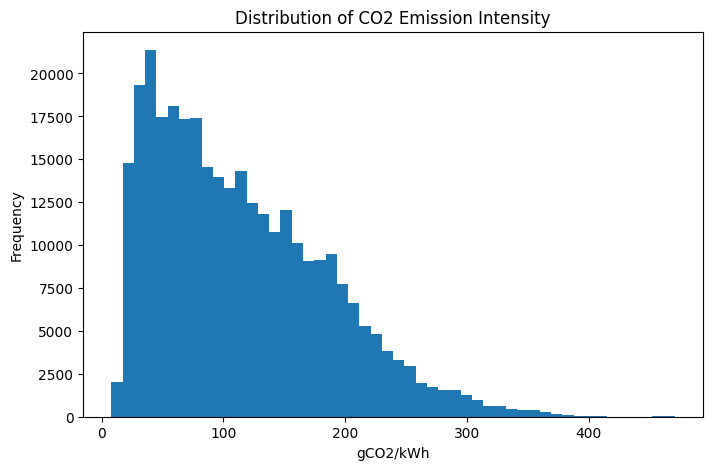

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(co2["CO2Emission"], bins=50)
plt.title("Distribution of CO2 Emission Intensity")
plt.xlabel("gCO2/kWh")
plt.ylabel("Frequency")
plt.show()

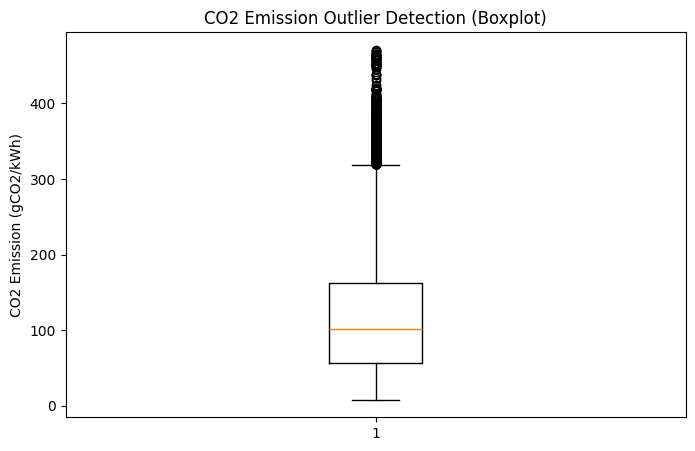

In [28]:
#Outlier Detection
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(co2["CO2Emission"])
plt.title("CO2 Emission Outlier Detection (Boxplot)")
plt.ylabel("CO2 Emission (gCO2/kWh)")
plt.show()

In [29]:
# Calculate IQR
Q1 = co2["CO2Emission"].quantile(0.25)
Q3 = co2["CO2Emission"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Count outliers
outliers = co2[(co2["CO2Emission"] < lower_bound) | (co2["CO2Emission"] > upper_bound)]

print("Number of outliers:", len(outliers))

outliers.head()

Lower bound: -100.5
Upper bound: 319.5
Number of outliers: 2784


,datetime_utc,PriceArea,CO2Emission
2762,2022-01-10 14:10:00+00:00,DK1,322.0
2772,2022-01-10 15:00:00+00:00,DK1,320.0
2773,2022-01-10 15:05:00+00:00,DK1,321.0
2805,2022-01-10 17:45:00+00:00,DK1,321.0
2806,2022-01-10 17:50:00+00:00,DK1,322.0


## Exploratory Data Analysis (EDA) – CO₂ Emission Intensity Dataset

Before aggregating the CO₂ dataset to hourly resolution and merging it with other datasets, a basic exploratory data analysis was conducted to understand the distribution, variability, and potential outliers in the CO₂ intensity series.

### Dataset Overview
The dataset contains **315,648 observations** at **5-minute resolution** covering the period **2022–2024** for the DK1 bidding zone.  
The timestamp column `datetime_utc` is stored in **UTC timezone** to avoid ambiguities caused by daylight saving time.

### Summary Statistics

| Statistic | Value |
|----------|------|
| Count | 315,648 |
| Mean | 114.78 gCO₂/kWh |
| Std | 71.09 |
| Minimum | 8 |
| 25th percentile | 57 |
| Median | 102 |
| 75th percentile | 162 |
| Maximum | 471 |

These values indicate that the CO₂ intensity in DK1 varies substantially depending on the generation mix and cross-border electricity exchanges.

### Distribution of CO₂ Intensity

A histogram of the CO₂ emission intensity shows a **right-skewed distribution**, where most observations fall between approximately **50 and 200 gCO₂/kWh**, while higher values occur less frequently.

This pattern is consistent with electricity systems where renewable generation (e.g., wind power) can significantly reduce CO₂ intensity during certain periods.

### Outlier Detection

Outliers were examined using the **Interquartile Range (IQR) method**.

Lower bound = **−100.5**  
Upper bound = **319.5**

Using this threshold, **2,784 observations** were flagged as potential outliers.

However, these high values are **not removed**, because they likely represent **real system conditions**, such as:

- periods with high fossil-fuel generation
- reduced renewable output
- increased electricity imports from higher-emission systems

Removing these values could distort the true variability of the electricity system. Therefore, the values were retained for the forecasting analysis.

### Conclusion of EDA

The dataset shows realistic variability and no impossible values. After handling missing timestamps and filling missing values through interpolation, the CO₂ intensity dataset is considered **clean, continuous, and ready for aggregation to hourly resolution**.

In [30]:
#Convert CO₂ (5-minute → hourly)
# Step 11: Aggregate CO2 emission from 5-minute to hourly while keeping DK1 label

# Select columns needed
co2_hourly = co2[["datetime_utc", "CO2Emission"]].copy()

# Set datetime as index
co2_hourly = co2_hourly.set_index("datetime_utc")

# Resample to hourly mean
co2_hourly = co2_hourly.resample("1h").mean()

# Add DK1 column back
co2_hourly["PriceArea"] = "DK1"

# Reset index
co2_hourly = co2_hourly.reset_index()

print("Shape of hourly CO2 dataset:", co2_hourly.shape)

display(co2_hourly.head())
display(co2_hourly.tail())


Shape of hourly CO2 dataset: (26304, 3)


,datetime_utc,CO2Emission,PriceArea
0,2022-01-01 00:00:00+00:00,63.000000,DK1
1,2022-01-01 01:00:00+00:00,68.750000,DK1
2,2022-01-01 02:00:00+00:00,72.583333,DK1
3,2022-01-01 03:00:00+00:00,77.250000,DK1
4,2022-01-01 04:00:00+00:00,79.750000,DK1


,datetime_utc,CO2Emission,PriceArea
26299,2024-12-31 19:00:00+00:00,22.083333,DK1
26300,2024-12-31 20:00:00+00:00,18.166667,DK1
26301,2024-12-31 21:00:00+00:00,25.583333,DK1
26302,2024-12-31 22:00:00+00:00,28.500000,DK1
26303,2024-12-31 23:00:00+00:00,9.666667,DK1


### Hourly Aggregation of CO₂ Intensity

The original CO₂ emission dataset was provided at 5-minute resolution.  
To align it with the weather dataset and electricity settlement dataset, which are available at hourly resolution, the CO₂ intensity series was aggregated to hourly frequency.

The hourly CO₂ intensity was computed as the mean of the twelve 5-minute observations within each hour.

The resulting dataset contains **26,304 hourly observations** covering the period **2022–2024**. The `PriceArea` column (DK1) was retained as a constant identifier for the bidding zone.

In [31]:
#Rename Column for Final Modeling Dataset
# Step 12: Rename CO2 column

co2_hourly = co2_hourly.rename(columns={"CO2Emission": "co2_intensity"})

print(co2_hourly.columns)

display(co2_hourly.head())

Index(['datetime_utc', 'co2_intensity', 'PriceArea'], dtype='str')


,datetime_utc,co2_intensity,PriceArea
0,2022-01-01 00:00:00+00:00,63.000000,DK1
1,2022-01-01 01:00:00+00:00,68.750000,DK1
2,2022-01-01 02:00:00+00:00,72.583333,DK1
3,2022-01-01 03:00:00+00:00,77.250000,DK1
4,2022-01-01 04:00:00+00:00,79.750000,DK1


In [32]:
#Final Hourly Continuity Check
#We should confirm there are no missing hours.
# Step 13: Verify hourly continuity

time_diff = co2_hourly["datetime_utc"].diff().value_counts()

print("Hourly time difference distribution:")
print(time_diff)

expected_interval = pd.Timedelta(hours=1)

all_correct = (co2_hourly["datetime_utc"].diff().dropna() == expected_interval).all()

print("\nAll timestamps follow 1-hour interval:", all_correct)

Hourly time difference distribution:
datetime_utc
0 days 01:00:00    26303
Name: count, dtype: int64

All timestamps follow 1-hour interval: True


### Final CO₂ Dataset Validation

After resampling the 5-minute CO₂ intensity data to hourly resolution, the dataset contains **26,304 observations**, covering the period **2022–2024**.

A time continuity check confirms that all timestamps follow a **1-hour interval**, indicating that no hourly observations are missing after aggregation.

The final dataset structure consists of:

- **datetime_utc** – timestamp in UTC
- **co2_intensity** – hourly average CO₂ emission intensity (gCO₂/kWh)
- **PriceArea** – electricity bidding zone identifier (DK1)

This hourly dataset will later be merged with the **weather dataset** using the `datetime_utc` timestamp.

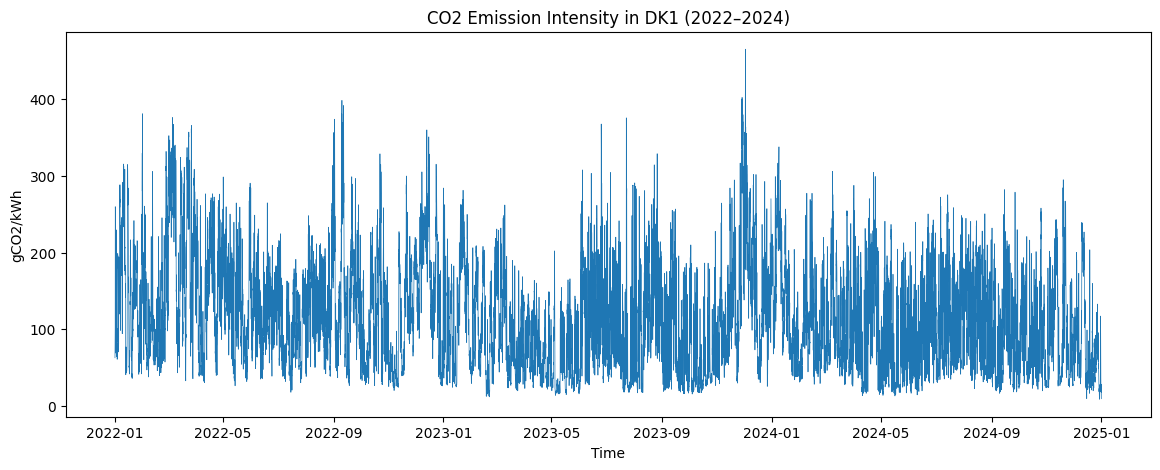

In [33]:
#CO₂ Time Series Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(co2_hourly["datetime_utc"], co2_hourly["co2_intensity"], linewidth=0.5)

plt.title("CO2 Emission Intensity in DK1 (2022–2024)")
plt.xlabel("Time")
plt.ylabel("gCO2/kWh")

plt.show()

### Time Series of CO₂ Emission Intensity

Higher CO₂ intensity values appear more frequently during some winter periods, although the pattern is strongly affected by renewable generation and cross-border exchanges.

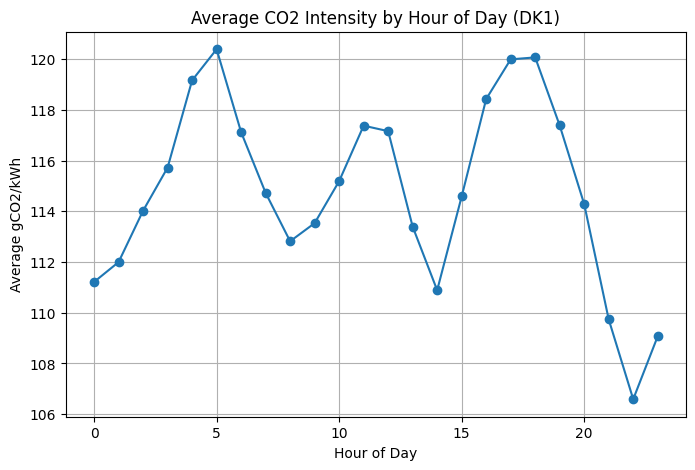

In [34]:
#average CO₂ intensity by hour of day.
# Step 15: Hour-of-day pattern

co2_hourly["hour"] = co2_hourly["datetime_utc"].dt.hour

hourly_pattern = co2_hourly.groupby("hour")["co2_intensity"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
hourly_pattern.plot(marker="o")

plt.title("Average CO2 Intensity by Hour of Day (DK1)")
plt.xlabel("Hour of Day")
plt.ylabel("Average gCO2/kWh")

plt.grid(True)
plt.show()

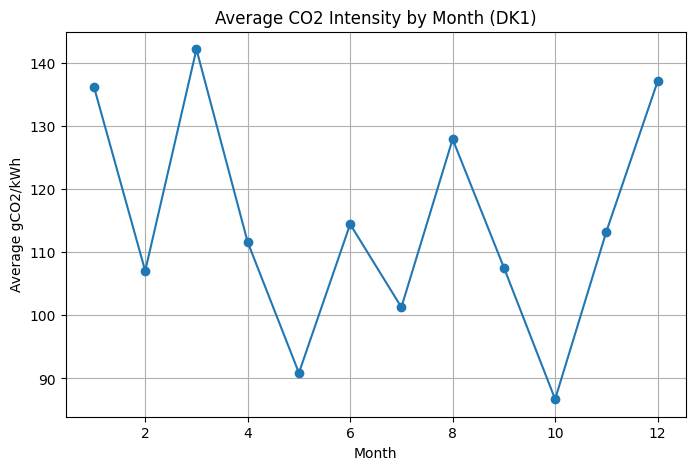

In [35]:
#Monthly Seasonality
# Step 16: Monthly pattern

co2_hourly["month"] = co2_hourly["datetime_utc"].dt.month

monthly_pattern = co2_hourly.groupby("month")["co2_intensity"].mean()

plt.figure(figsize=(8,5))
monthly_pattern.plot(marker="o")

plt.title("Average CO2 Intensity by Month (DK1)")
plt.xlabel("Month")
plt.ylabel("Average gCO2/kWh")

plt.grid(True)
plt.show()

Hour-of-day pattern

plot shows:

Peak around 5–6 AM

Another peak around 17–18 PM

Lowest values late evening (21–22)

This likely corresponds to electricity demand cycles.


Monthly pattern

plot shows:

Higher emissions:

Winter months
Jan
Mar
Dec

Lower emissions:

Summer/autumn
May
Oct

This indicates renewable energy impact and seasonal demand.

In [36]:
#Clean Dataset Before Saving
# Remove temporary EDA columns
co2_hourly = co2_hourly[["datetime_utc", "co2_intensity", "PriceArea"]]

display(co2_hourly.head())
print(co2_hourly.shape)

,datetime_utc,co2_intensity,PriceArea
0,2022-01-01 00:00:00+00:00,63.000000,DK1
1,2022-01-01 01:00:00+00:00,68.750000,DK1
2,2022-01-01 02:00:00+00:00,72.583333,DK1
3,2022-01-01 03:00:00+00:00,77.250000,DK1
4,2022-01-01 04:00:00+00:00,79.750000,DK1


(26304, 3)


In [37]:
co2_hourly.to_csv("co2_dk1_hourly_2022_2024.csv", index=False)

### Final CO₂ Dataset Export

The processed CO₂ emission dataset was exported as a CSV file after hourly aggregation and validation.

The dataset contains:

- **26,304 hourly observations**
- Period: **2022–2024**
- Region: **DK1**

Variables included in the dataset:

- `datetime_utc` – timestamp in UTC
- `co2_intensity` – hourly CO₂ emission intensity (gCO₂/kWh)
- `PriceArea` – electricity bidding zone identifier (DK1)

This dataset will later be merged with the weather dataset and electricity consumption dataset using the `datetime_utc` timestamp.